In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

## Step 1 — Data Acquisition / Preprocessing

In [2]:
df = pd.read_csv('Melbourne_housing_FULL.csv')

# 3 suburbs
suburbs = ['Richmond', 'Reservoir', 'Bentleigh East']
df = df[df['Suburb'].isin(suburbs)].copy()

# Keep relevant column
cols = ['Suburb', 'Rooms', 'Type', 'Price', 'Distance', 'Bathroom',
        'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Date']
df = df[cols].dropna(subset=['Price'])

print('Shape suburb filter:', df.shape)
print('\nRecords per suburb:')
print(df['Suburb'].value_counts())
df.head()

Shape suburb filter: (1659, 11)

Records per suburb:
Suburb
Reservoir         727
Bentleigh East    493
Richmond          439
Name: count, dtype: int64


,Suburb,Rooms,Type,Price,Distance,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Date
1357,Bentleigh East,2,h,1410000.0,13.9,1.0,2.0,768.0,NaN,NaN,3/09/2016
1358,Bentleigh East,3,t,990000.0,13.9,NaN,NaN,NaN,NaN,NaN,3/09/2016
1359,Bentleigh East,3,h,1057000.0,13.9,NaN,NaN,NaN,NaN,NaN,3/09/2016
1360,Bentleigh East,3,t,760000.0,13.9,1.0,2.0,287.0,NaN,NaN,3/09/2016
1361,Bentleigh East,2,h,825000.0,13.9,2.0,1.0,176.0,125.0,2008.0,3/09/2016


In [3]:
# Parse date and extract year/month
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df['SaleYear']  = df['Date'].dt.year
df['SaleMonth'] = df['Date'].dt.month
df = df.drop(columns=['Date'])

# feature: property age
df['PropertyAge'] = df['SaleYear'] - df['YearBuilt']

# Type / Suburb
df = pd.get_dummies(df, columns=['Type', 'Suburb'], drop_first=True)

# Fill remaining with median
df = df.fillna(df.median(numeric_only=True))

print('Final shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())

Final shape: (1659, 15)
Missing values: 0


## Step 2 — Data Analysis

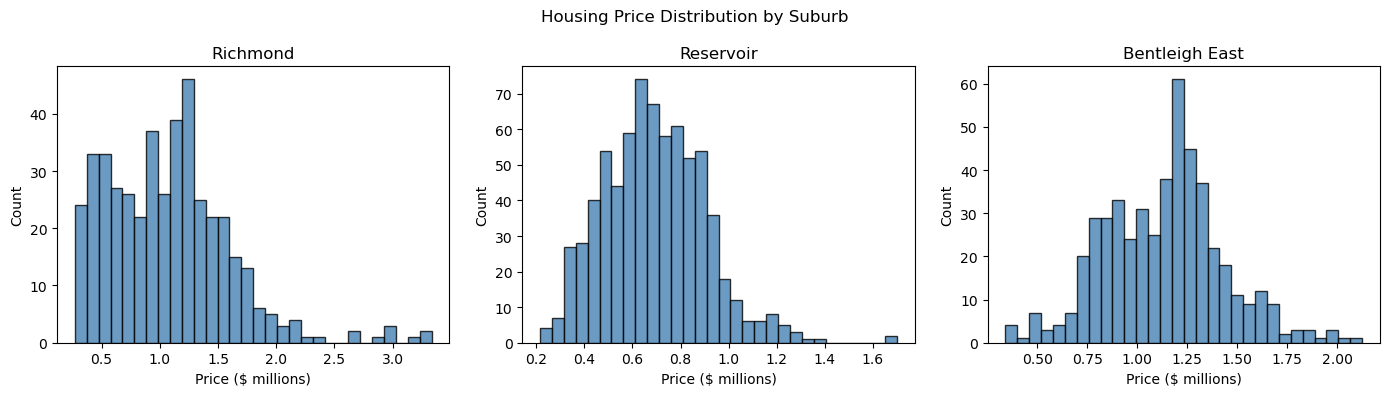

In [4]:
# Price distribution by suburb
raw = pd.read_csv('Melbourne_housing_FULL.csv')
raw = raw[raw['Suburb'].isin(suburbs)].dropna(subset=['Price'])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, suburb in zip(axes, suburbs):
    data = raw[raw['Suburb'] == suburb]['Price'] / 1e6
    ax.hist(data, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(suburb)
    ax.set_xlabel('Price ($ millions)')
    ax.set_ylabel('Count')
plt.suptitle('Housing Price Distribution by Suburb')
plt.tight_layout()
plt.show()

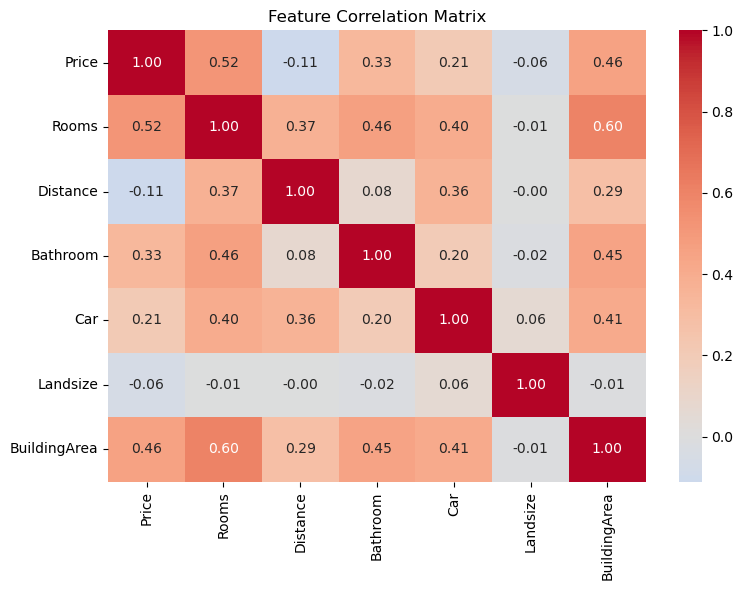

In [5]:
# Feature versus price
corr_cols = ['Price', 'Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'BuildingArea']
corr = raw[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

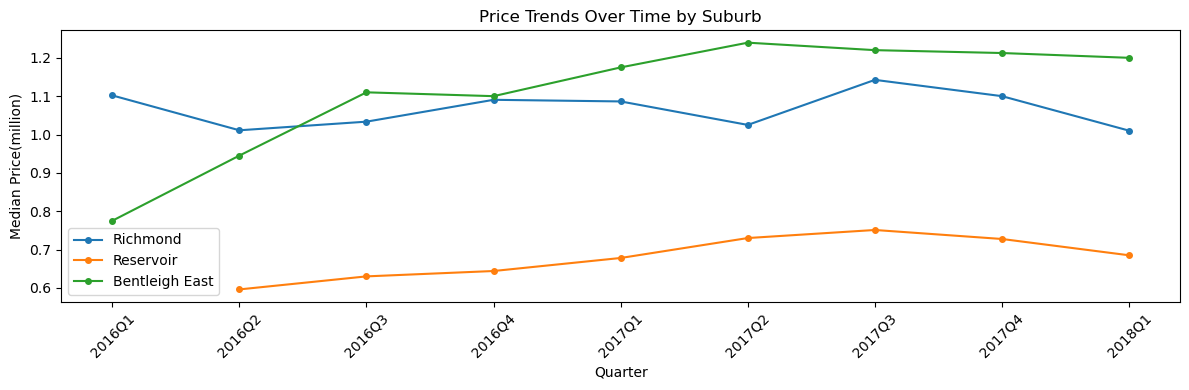

In [6]:
# Price by suburb vs time
raw['Date'] = pd.to_datetime(raw['Date'], dayfirst=True)
raw['YearMonth'] = raw['Date'].dt.to_period('Q')
trend = raw.groupby(['YearMonth', 'Suburb'])['Price'].median().reset_index()
trend['YearMonth'] = trend['YearMonth'].astype(str)

plt.figure(figsize=(12, 4))
for suburb in suburbs:
    s = trend[trend['Suburb'] == suburb]
    plt.plot(s['YearMonth'], s['Price'] / 1e6, marker='o', label=suburb, markersize=4)
plt.xticks(rotation=45)
plt.xlabel('Quarter'); plt.ylabel('Median Price(million)')
plt.title('Price Trends Over Time by Suburb')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 800x400 with 0 Axes>

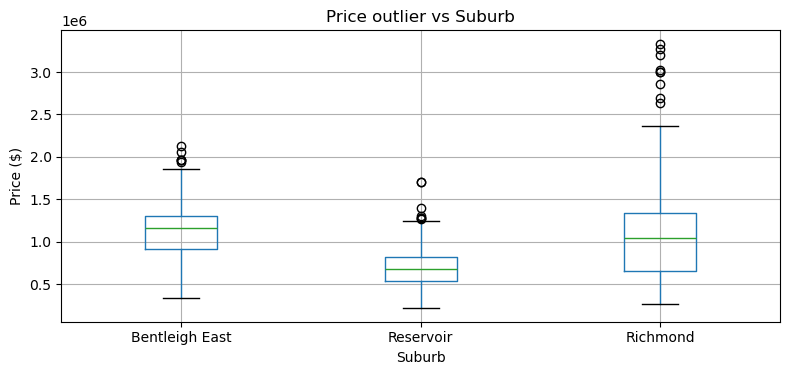

In [7]:
# Outlier boxplot
plt.figure(figsize=(8, 4))
raw.boxplot(column='Price', by='Suburb', figsize=(8, 4))
plt.suptitle('')
plt.title('Price outlier vs Suburb')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

## Step 3 — Model Development & Evaluation

In [8]:
X = df.drop(columns=['Price'])
y = df['Price']

# Standardise features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

models = {
    'Linear Regression':    LinearRegression(),
    'Ridge Regression':     Ridge(alpha=1.0),
    'Random Forest':        RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=100, random_state=42)
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    mae  = -cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_mean_absolute_error').mean()
    rmse = np.sqrt(-cross_val_score(model, X_scaled, y, cv=kf, scoring='neg_mean_squared_error').mean())
    r2   = cross_val_score(model, X_scaled, y, cv=kf, scoring='r2').mean()
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f'{name:<25} MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.4f}')

results_df = pd.DataFrame(results)

Linear Regression         MAE=166,047  RMSE=234,899  R2=0.6593
Ridge Regression          MAE=165,938  RMSE=234,853  R2=0.6594
Random Forest             MAE=141,304  RMSE=214,046  R2=0.7177
Gradient Boosting         MAE=137,462  RMSE=209,980  R2=0.7284


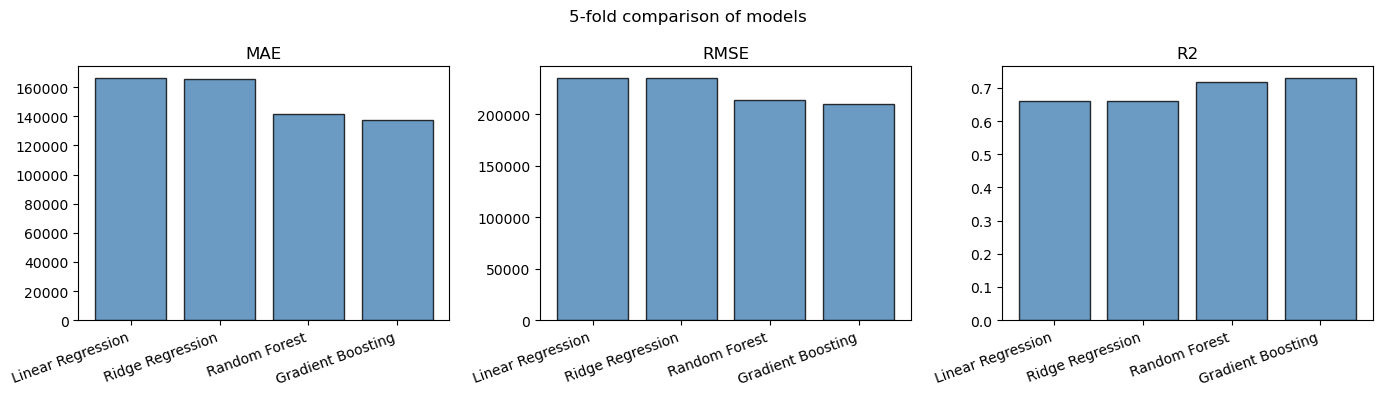

In [9]:
# model comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    ax.bar(results_df['Model'], results_df[metric], color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_title(metric); ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
plt.suptitle('5-fold comparison of models')
plt.tight_layout()
plt.show()

## Step 4 — Feature Importance

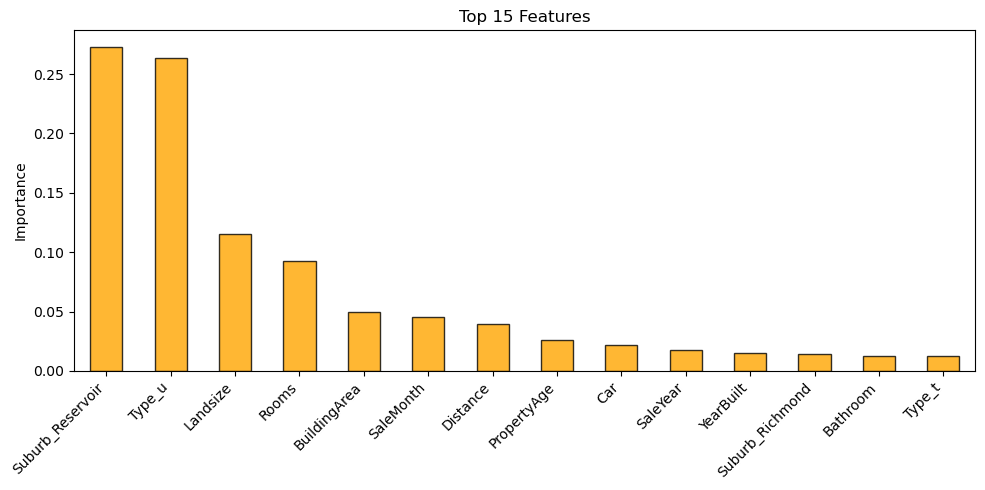

Top 5 features:
Suburb_Reservoir    0.273112
Type_u              0.263513
Landsize            0.114961
Rooms               0.092452
BuildingArea        0.049830
dtype: float64


In [10]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(15).plot(kind='bar', color='orange', edgecolor='black', alpha=0.8)
plt.title('Top 15 Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(importances.head())

## Step 5 — Web Demo (Streamlit)

Ran the file `app.py` in terminal with: `streamlit run app.py`

## Step 6 — LLM Comparison

In [11]:
# compare LLM predictions vs model predictions (1 fold)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)
rf_preds = rf_final.predict(X_test)

# Sample 5 properties to send to LLM
sample = pd.DataFrame(X_test[:5], columns=X.columns)
sample['Actual_Price'] = y_test.values[:5]
sample['RF_Predicted'] = rf_preds[:5]
print('Sample properties for LLM comparison:')
print(sample[['Rooms', 'Distance', 'Bathroom', 'Actual_Price', 'RF_Predicted']].to_string())

rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2   = r2_score(y_test, rf_preds)
print(f'\nRandom Forest (test set): MAE={rf_mae:,.0f}  RMSE={rf_rmse:,.0f}  R2={rf_r2:.4f}')
print('\nLLM comparison: prompt the sample properties to ChatGPT/Claude and record price estimates.')
print('computes MAE between LLM estimates and actual prices.')

Sample properties for LLM comparison:
      Rooms  Distance  Bathroom  Actual_Price  RF_Predicted
0 -0.938204 -1.650670 -0.561668      590000.0  5.510146e+05
1  1.400610  0.297814  1.283495      750000.0  9.696100e+05
2 -0.938204 -1.650670 -0.561668     1270000.0  1.354760e+06
3  0.231203  0.474949 -0.561668      953000.0  8.988260e+05
4  0.231203  0.474949 -0.561668      770000.0  8.204978e+05

Random Forest (test set): MAE=144,992  RMSE=236,692  R2=0.6766

LLM comparison: prompt the sample properties to ChatGPT/Claude and record price estimates.
computes MAE between LLM estimates and actual prices.


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

rf_final = RandomForestRegressor(n_estimators=100, random_state=42)
rf_final.fit(X_train, y_train)
rf_preds = rf_final.predict(X_test)

mae  = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2   = r2_score(y_test, rf_preds)

print('Random Forest test set performance:')
print('MAE : {:,.0f}'.format(mae))
print('RMSE: {:,.0f}'.format(rmse))
print('R2  : {:.4f}'.format(r2))

# LLM estimate from GPT
sample = pd.DataFrame(X_test[:5], columns=X.columns)
sample['Actual_Price']  = y_test.values[:5]
sample['RF_Predicted']  = rf_preds[:5]
sample['LLM_Estimated'] = [1720000, 2680000, 905000, 1465000, 1535000]

print('\nLLM vs RF :')
print(sample[['Actual_Price', 'RF_Predicted', 'LLM_Estimated']].to_string())
print('\nRF MAE:  {:,.0f}'.format(mean_absolute_error(sample['Actual_Price'], sample['RF_Predicted'])))
print('LLM MAE: {:,.0f}'.format(mean_absolute_error(sample['Actual_Price'], sample['LLM_Estimated'])))

Random Forest test set performance:
MAE : 144,992
RMSE: 236,692
R2  : 0.6766

LLM vs RF :
   Actual_Price  RF_Predicted  LLM_Estimated
0      590000.0  5.510146e+05        1720000
1      750000.0  9.696100e+05        2680000
2     1270000.0  1.354760e+06         905000
3      953000.0  8.988260e+05        1465000
4      770000.0  8.204978e+05        1535000

RF MAE:  89,605
LLM MAE: 940,400
